In [16]:
pip install ipykernel

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import yfinance as yf
import pandas as pd

print("Environment linked successfully!")

Environment linked successfully!


In [18]:
# 1. Define the ticker symbol
ticker = "MSFT"

# 2. Download the data 
# You can use specific dates like start="2021-08-01", end="2026-08-01"
# Or just grab the last 5 years dynamically:
df = yf.download(ticker, period="5y")

# 3. Save it directly to your B:\Stock Prediction folder
df.to_csv("MSFT_historical_data.csv")

print("Data successfully downloaded and saved!")

[*********************100%***********************]  1 of 1 completed


Data successfully downloaded and saved!


In [19]:
df

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2021-08-13,281.047180,281.095153,277.640239,277.813007,18249000
2021-08-16,282.726624,282.937758,278.331197,281.373448,22507600
2021-08-17,281.267914,281.603814,279.348520,280.605750,20075300
2021-08-18,279.546783,283.479454,279.104457,280.806391,21813000
2021-08-19,285.354401,286.027486,277.537155,277.585220,29850500
...,...,...,...,...,...
2026-08-06,499.859985,501.559998,488.519989,488.549988,36441500
2026-08-07,499.989990,505.179993,498.730011,499.209991,28846200


In [20]:
# 1. Drop the 'Ticker' level (the 'MSFT' row) from the column headers
df.columns = df.columns.droplevel('Ticker')

In [21]:
# 2. Reset the index so 'Date' becomes a standard, selectable column
df = df.reset_index()

# 3. Now your original print command will work perfectly!
print(df[['Date', 'Close']])

Price       Date       Close
0     2021-08-13  281.047180
1     2021-08-16  282.726624
2     2021-08-17  281.267914
3     2021-08-18  279.546783
4     2021-08-19  285.354401
...          ...         ...
1249  2026-08-06  499.859985
1250  2026-08-07  499.989990
1251  2026-08-10  506.059998
1252  2026-08-11  503.809998
1253  2026-08-12  492.429993

[1254 rows x 2 columns]


In [22]:
print(df['Date'])

0      2021-08-13
1      2021-08-16
2      2021-08-17
3      2021-08-18
4      2021-08-19
          ...    
1249   2026-08-06
1250   2026-08-07
1251   2026-08-10
1252   2026-08-11
1253   2026-08-12
Name: Date, Length: 1254, dtype: datetime64[s]


In [23]:
df.index = df.pop('Date')
df

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-08-13,281.047180,281.095153,277.640239,277.813007,18249000
2021-08-16,282.726624,282.937758,278.331197,281.373448,22507600
2021-08-17,281.267914,281.603814,279.348520,280.605750,20075300
2021-08-18,279.546783,283.479454,279.104457,280.806391,21813000
2021-08-19,285.354401,286.027486,277.537155,277.585220,29850500
...,...,...,...,...,...
2026-08-06,499.859985,501.559998,488.519989,488.549988,36441500
2026-08-07,499.989990,505.179993,498.730011,499.209991,28846200
2026-08-10,506.059998,513.729980,502.269989,503.440002,31206100


In [24]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


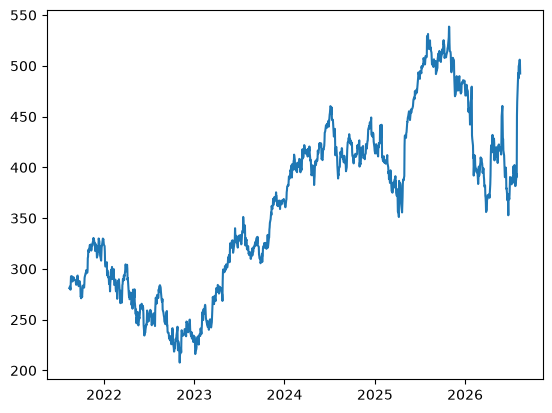

In [25]:
import matplotlib.pyplot as plt

plt.plot(df.index, df['Close'])

In [ ]:
import datetime

def str_to_datetime(s):
  split = s.split('-')
  year, month, day = int(split[0]), int(split[1]), int(split[2])
  return datetime.datetime(year=year, month=month, day=day)

# Why This Matters (Overall)

Machine learning models — especially for time series — don't understand "time" implicitly the way humans do. A model like an LSTM or a linear regressor just sees fixed-size input vectors and one output. Windowing is the bridge that converts a raw time-ordered sequence into that (input, output) format. Without this step, we literally cannot train a supervised model on sequential data like stock prices, sensor readings, or website traffic.

The resulting windowed_df would look like:

Target Date	Target-3	Target-2	Target-1	Target
2021-08-10	145.2	146.1	147.0	148.3
2021-08-11	146.1	147.0	148.3	149.1

Each row overlaps the previous one by n-1 values — that's the "sliding" part.

Other Applications of This Exact Pattern
Any univariate time series forecasting: temperature prediction, electricity demand, website traffic, sales forecasting.
Sensor/IoT data: predicting next reading from the last k sensor readings (anomaly detection, predictive maintenance).
Audio/signal processing: windowing raw signal into frames for feature extraction.
NLP-adjacent: this is conceptually the same idea as n-gram context windows (predict next word from last n words) — just numeric instead of tokens.
Reinforcement learning state stacking: stacking the last n frames/observations as the current "state" (e.g., Atari DQN uses 4 stacked frames).
Feature engineering for classical ML: turning any time-ordered tabular data into lag features for XGBoost/Random Forest regression, not just deep learning.

# Weaknesses Worth Knowing. 
The return inside the error branch kills the entire function — if window n is too large near the start of the data, we get None back instead of a partial result. A continue/skip would be safer.
Fragile date parsing — the manual string-splitting to rebuild next_date is unnecessary; pd.Timestamp(next_week.index[1]).to_pydatetime() does the same thing in one line and won't break on format changes.
Dead code — the bare X[:, i] line does nothing.
Uses datetime and pd without importing them in this snippet (only numpy is imported here) — so this snippet assumes pandas, datetime, and a str_to_datetime helper exist elsewhere.
Off-by-one risk near holidays/weekends — .head(2).tail(1) assumes the next available index row is exactly what you want; that's usually true but depends on your data having no gaps beyond a week.

In [39]:
import numpy as np

def df_to_windowed_df(dataframe, first_date_str, last_date_str, n=3):
  first_date = str_to_datetime(first_date_str)
  last_date  = str_to_datetime(last_date_str)

  target_date = first_date
  
  dates = []
  X, Y = [], []

  last_time = False
  while True:
    df_subset = dataframe.loc[:target_date].tail(n+1)
   
# Laymen: "If there isn't enough history yet (e.g., we're near the very beginning of the data and don't have 3 prior days), stop and complain."
    if len(df_subset) != n+1:
      print(f'Error: Window of size {n} is too large for date {target_date}')
      return

    values = df_subset['Close'].to_numpy()
    x, y = values[:-1], values[-1]

    dates.append(target_date)
    X.append(x)
    Y.append(y)

#     "Save this date and this clue/answer pair into our lists."
# Technical: Appends the row's date, feature vector, and target scalar to their respective lists.
    next_week = dataframe.loc[target_date:target_date+datetime.timedelta(days=7)]
    next_datetime_str = str(next_week.head(2).tail(1).index.values[0])
    
#"Look at the week ahead, and find the very next trading day after today 
# (skipping weekends/holidays automatically because we just look at what data actually exists)."
# Technical: Slices a 7-day window starting at target_date. .head(2).tail(1) is 
# a slightly roundabout way of saying "give me the second row in this slice" — 
# since the first row is target_date itself, the second row is the next available date in the index.

    next_date_str = next_datetime_str.split('T')[0]
    year_month_day = next_date_str.split('-')
    year, month, day = year_month_day
    next_date = datetime.datetime(day=int(day), month=int(month), year=int(year))
  
# Take that messy date-with-time text (like 2021-08-11T00:00:00.000000000), 
# chop it down to just the date part, split it into year/month/day, 
# and rebuild it as a clean date object."
  
    if last_time:
      break
    
#  If we already flagged 'this is the last one,' stop now   

    target_date = next_date

    if target_date == last_date:
      last_time = True

# Move our pointer to the next day. If that next day is our end date, mark 'one more round and we're done. 
    
  ret_df = pd.DataFrame({})
  ret_df['Target Date'] = dates

#Start building the final results table with a column of dates

  X = np.array(X)
  for i in range(0, n):
    X[:, i]
    ret_df[f'Target-{n-i}'] = X[:, i]
  
  ret_df['Target'] = Y

  return ret_df

# Start date adjusted to account for your actual data timeline
windowed_df = df_to_windowed_df(df, 
                                '2021-08-18',  # A safe date after your data begins
                                '2022-08-18',  # One year later
                                n=3)

# Display the resulting dataframe
windowed_df

,Target Date,Target-3,Target-2,Target-1,Target
0,2021-08-18,281.047180,282.726624,281.267914,279.546783
1,2021-08-19,282.726624,281.267914,279.546783,285.354401
2,2021-08-20,281.267914,279.546783,285.354401,292.652435
3,2021-08-23,279.546783,285.354401,292.652435,292.931274
4,2021-08-24,285.354401,292.652435,292.931274,290.979370
...,...,...,...,...,...
248,2022-08-12,273.134583,279.771851,277.701355,282.432587
249,2022-08-15,279.771851,277.701355,282.432587,283.941956
250,2022-08-16,277.701355,282.432587,283.941956,283.206604
251,2022-08-17,282.432587,283.941956,283.206604,282.460022


In [36]:
def windowed_df_to_date_X_y(windowed_dataframe):
  df_as_np = windowed_dataframe.to_numpy()

  dates = df_as_np[:, 0]

  middle_matrix = df_as_np[:, 1:-1]
  X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))

  Y = df_as_np[:, -1]

  return dates, X.astype(np.float32), Y.astype(np.float32)

dates, X, y = windowed_df_to_date_X_y(windowed_df)

dates.shape, X.shape, y.shape

((253,), (253, 3, 1), (253,))